In [5]:
import pandas as pd
import numpy as np
from datetime import datetime

In [6]:
# Read the CSV file
df = pd.read_csv(r'C:\Users\samad_dthqblr\Downloads\DSE_Data.csv')

In [7]:
df.info()
df.tail(10)

<class 'pandas.DataFrame'>
RangeIndex: 1523921 entries, 0 to 1523920
Data columns (total 7 columns):
 #   Column        Non-Null Count    Dtype  
---  ------        --------------    -----  
 0   Trading_Code  1523921 non-null  str    
 1   Date          1523921 non-null  str    
 2   Open          1523921 non-null  float64
 3   High          1523921 non-null  float64
 4   Low           1523921 non-null  float64
 5   Close         1523921 non-null  float64
 6   Volume        1523919 non-null  float64
dtypes: float64(5), str(2)
memory usage: 81.4 MB


,Trading_Code,Date,Open,High,Low,Close,Volume
1523911,BDLAMPS,1999-01-02,588.00,588.00,588.00,588.00,10.0
1523912,POPULARLIF,1999-01-02,1010.00,1010.00,1010.00,1010.00,25.0
1523913,ISLAMIBANK,1999-01-02,2009.00,2009.00,2003.00,2005.00,26.0
1523914,APEXTANRY,1999-01-02,215.00,216.50,214.00,214.75,940.0
1523915,ULC,1999-01-02,920.00,920.00,920.00,920.00,40.0
1523916,NBL,1999-01-02,63.75,63.75,63.25,63.50,260.0
1523917,AFTABAUTO,1999-01-02,164.50,165.00,164.00,164.25,410.0
1523918,QSMDRYCELL,1999-01-02,21.20,21.20,21.00,21.10,31700.0
1523919,EXCELSHOE,1999-01-02,66.75,67.25,65.50,66.50,10500.0
1523920,APEXSPINN,1999-01-02,109.50,109.50,107.25,109.00,0.0


In [8]:
# Convert the Date column to datetime
df['Date'] = pd.to_datetime(df['Date'])

In [9]:
# Check for missing values
df.isna().value_counts()
df.tail(10)

,Trading_Code,Date,Open,High,Low,Close,Volume
1523911,BDLAMPS,1999-01-02,588.00,588.00,588.00,588.00,10.0
1523912,POPULARLIF,1999-01-02,1010.00,1010.00,1010.00,1010.00,25.0
1523913,ISLAMIBANK,1999-01-02,2009.00,2009.00,2003.00,2005.00,26.0
1523914,APEXTANRY,1999-01-02,215.00,216.50,214.00,214.75,940.0
1523915,ULC,1999-01-02,920.00,920.00,920.00,920.00,40.0
1523916,NBL,1999-01-02,63.75,63.75,63.25,63.50,260.0
1523917,AFTABAUTO,1999-01-02,164.50,165.00,164.00,164.25,410.0
1523918,QSMDRYCELL,1999-01-02,21.20,21.20,21.00,21.10,31700.0
1523919,EXCELSHOE,1999-01-02,66.75,67.25,65.50,66.50,10500.0
1523920,APEXSPINN,1999-01-02,109.50,109.50,107.25,109.00,0.0


In [10]:
# Check the rows where Volume is missing
df.loc[df['Volume'].isna()].head(10)

,Trading_Code,Date,Open,High,Low,Close,Volume
884561,PREMIERBAN,2015-09-03,9.6,9.7,9.5,9.6,NaN
921570,ARAMIT,2015-03-08,251.0,264.0,251.0,255.5,NaN


In [11]:
# Remove rows with missing values
df.dropna(inplace=True)

In [12]:
# Check and remove duplicate records
df.duplicated().value_counts()
df.drop_duplicates(inplace=True)

In [13]:
# Remove rows where any of the main numerical fields contains zero
initial_rows = len(df)

df_filtered_zeros = df[
    (df['Open'] != 0) &
    (df['High'] != 0) &
    (df['Low'] != 0) &
    (df['Close'] != 0) &
    (df['Volume'] != 0)
]

rows_removed = initial_rows - len(df_filtered_zeros)

print(
    f"Removed {rows_removed} rows containing zero values "
    "in key numerical columns."
)

df = df_filtered_zeros.copy()

display(df.head())

Removed 25554 rows containing zero values in key numerical columns.


,Trading_Code,Date,Open,High,Low,Close,Volume
0,SIBL,2025-04-08,9.9,10.0,9.8,9.9,359773.0
1,MEGHNALIFE,2025-04-08,54.5,56.6,54.1,56.1,610711.0
2,BPML,2025-04-08,41.1,41.7,40.0,40.2,482031.0
3,CROWNCEMNT,2025-04-08,47.9,50.9,47.5,50.0,104860.0
5,EASTLAND,2025-04-08,18.4,18.5,18.3,18.5,50145.0


In [14]:
# Trading codes that are not needed for the stock-price analysis
trading_codes_to_remove = [
    'DSES', 'DS30', 'DSEX', 'BEXGSUKUK', 'IBBLPBOND', 'AIBLPBOND',
    'PBLPBOND', 'SJIBLPBOND', 'IBBL2PBOND', 'APSCLBOND', 'ABBLPBOND',
    'SEB1PBOND', 'DBLPBOND', 'PREBPBOND', 'MBPLCPBOND', 'BANKASI1PB',
    'UCB2PBOND', 'CBLPBOND', 'BRACSCBOND', 'ACIZCBOND', 'FBFIF',
    'GLDNJMF', 'ICBSONALI1', 'ICBEPMF1S1', 'ABB1STMF', 'PF1STMF',
    'POPULAR1MF', 'RELIANCE1', 'EBL1STMF', 'LRGLOBMF1', 'EBLNRBMF',
    'TRUSTB1MF', 'ICB3RDNRB', 'MBL1STMF', 'GRAMEENS2', 'GREENDELMF',
    'ICBAMCL2ND', 'NCCBLMF1', 'AIBL1STIMF', 'SEMLFBSLGF', 'SEMLLECMF',
    'DBH1STMF', 'SEMLIBBLSF', 'PHPMF1', 'ICBAGRANI1', 'CAPITECGBF',
    'PRIME1ICBA', 'EXIM1STMF', '1JANATAMF', 'CAPMIBBLMF', 'VAMLRBBF',
    'IFIC1STMF', 'IFILISLMF1', 'CAPMBDBLMF', 'VAMLBDMF1', 'ATCSLGF',
    'NLI1STMF', 'SEBL1STMF', 'ICB2NDNRB', 'ICB1STNRB', 'GRAMEEN1',
    'AIMS1STMF', 'ICBAMCL1ST'
]

initial_df_shape = df.shape

df = df[~df['Trading_Code'].isin(trading_codes_to_remove)]

print(f"DataFrame shape before removal: {initial_df_shape}")
print(f"DataFrame shape after removal: {df.shape}")

DataFrame shape before removal: (1434451, 7)
DataFrame shape after removal: (1307591, 7)


In [15]:
# Check once again for zero values after removing the unwanted codes
initial_rows = len(df)

df_filtered_zeros = df[
    (df['Open'] != 0) &
    (df['High'] != 0) &
    (df['Low'] != 0) &
    (df['Close'] != 0) &
    (df['Volume'] != 0)
]

rows_removed = initial_rows - len(df_filtered_zeros)

print(
    f"Removed {rows_removed} rows containing zero values "
    "in key numerical columns."
)

df = df_filtered_zeros.copy()

display(df.head())

Removed 0 rows containing zero values in key numerical columns.


,Trading_Code,Date,Open,High,Low,Close,Volume
0,SIBL,2025-04-08,9.9,10.0,9.8,9.9,359773.0
1,MEGHNALIFE,2025-04-08,54.5,56.6,54.1,56.1,610711.0
2,BPML,2025-04-08,41.1,41.7,40.0,40.2,482031.0
3,CROWNCEMNT,2025-04-08,47.9,50.9,47.5,50.0,104860.0
5,EASTLAND,2025-04-08,18.4,18.5,18.3,18.5,50145.0


In [16]:
# Data quality checks
scores = {}

# Completeness: check for missing values
total_values = df.shape[0] * df.shape[1]
missing_values = df.isnull().sum().sum()

completeness_score = (
    (total_values - missing_values) / total_values
) * 100

scores["Completeness Score (%)"] = round(completeness_score, 2)

# Consistency: check for duplicate records
duplicate_count = df.duplicated().sum()

consistency_score = (
    (len(df) - duplicate_count) / len(df)
) * 100

scores["Consistency Score (%)"] = round(consistency_score, 2)

# Validity: check whether the values follow the expected rules
validity_results = []

# Prices should not be negative
for col in ['Open', 'High', 'Low', 'Close']:
    if col in df.columns:
        valid_price = (df[col] >= 0).mean() * 100
        validity_results.append(valid_price)

# Trading volume should not be negative
if 'Volume' in df.columns:
    valid_volume = (df['Volume'] >= 0).mean() * 100
    validity_results.append(valid_volume)

# High price should be greater than or equal to Low price
if 'High' in df.columns and 'Low' in df.columns:
    valid_high_low = (df['High'] >= df['Low']).mean() * 100
    validity_results.append(valid_high_low)

# Open price should fall between the day's High and Low
if 'Open' in df.columns and 'High' in df.columns and 'Low' in df.columns:
    valid_open_high = (df['Open'] <= df['High']).mean() * 100
    validity_results.append(valid_open_high)

    valid_open_low = (df['Open'] >= df['Low']).mean() * 100
    validity_results.append(valid_open_low)

# Dates should not be in the future
if 'Date' in df.columns and pd.api.types.is_datetime64_any_dtype(df['Date']):
    valid_date = (df['Date'] <= datetime.now()).mean() * 100
    validity_results.append(valid_date)

if len(validity_results) > 0:
    validity_score = sum(validity_results) / len(validity_results)
else:
    validity_score = 100

scores["Validity Score (%)"] = round(validity_score, 2)

# Overall cleaning score
overall_score = (
    completeness_score +
    consistency_score +
    validity_score
) / 3

scores["Overall Cleaning Score (%)"] = round(overall_score, 2)

cleaning_report = pd.DataFrame(
    scores.items(),
    columns=["Quality Measure", "Score (%)"]
)

display(cleaning_report)

# Give a simple summary of the cleaning result
if overall_score >= 95:
    print(
        "Excellent: "
        "Data cleaning is complete. "
        "Dataset is ready for analysis."
    )
elif overall_score >= 85:
    print(
        "Good: "
        "Dataset is usable, but minor cleaning may be required."
    )
else:
    print(
        "Data cleaning is incomplete. "
        "Further cleaning is required."
    )

,Quality Measure,Score (%)
0,Completeness Score (%),100.0
1,Consistency Score (%),100.0
2,Validity Score (%),100.0
3,Overall Cleaning Score (%),100.0


Excellent: Data cleaning is complete. Dataset is ready for analysis.


## Exploratory Data Analysis

In [17]:
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns

Analyzing trends for: BXPHARMA


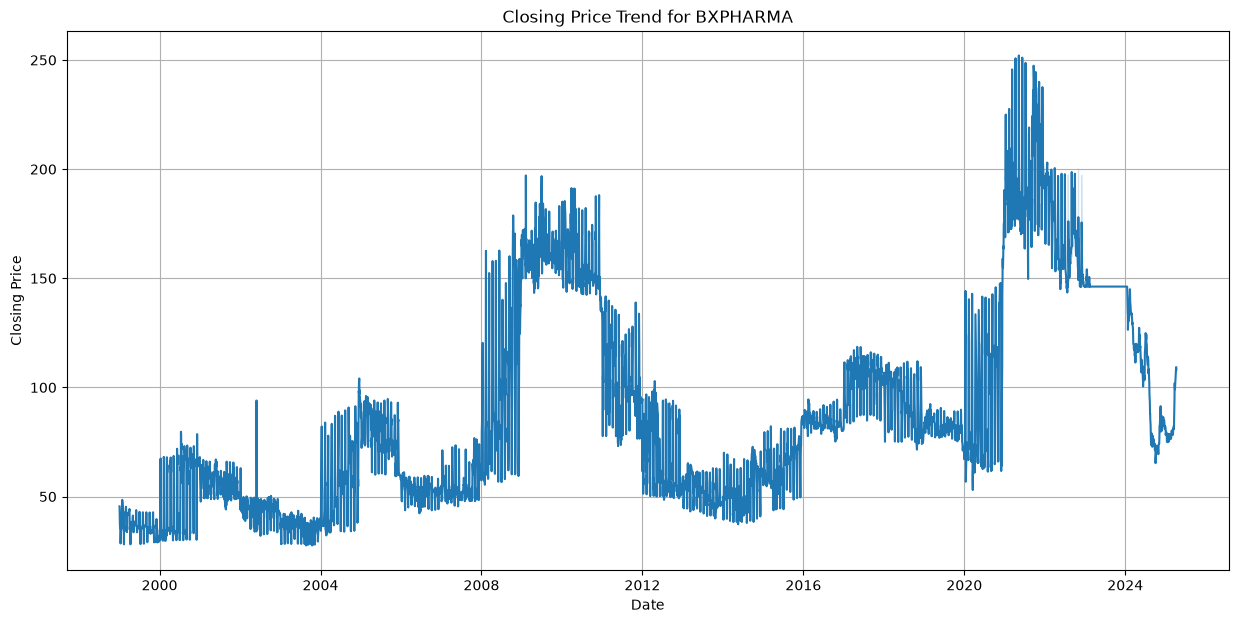

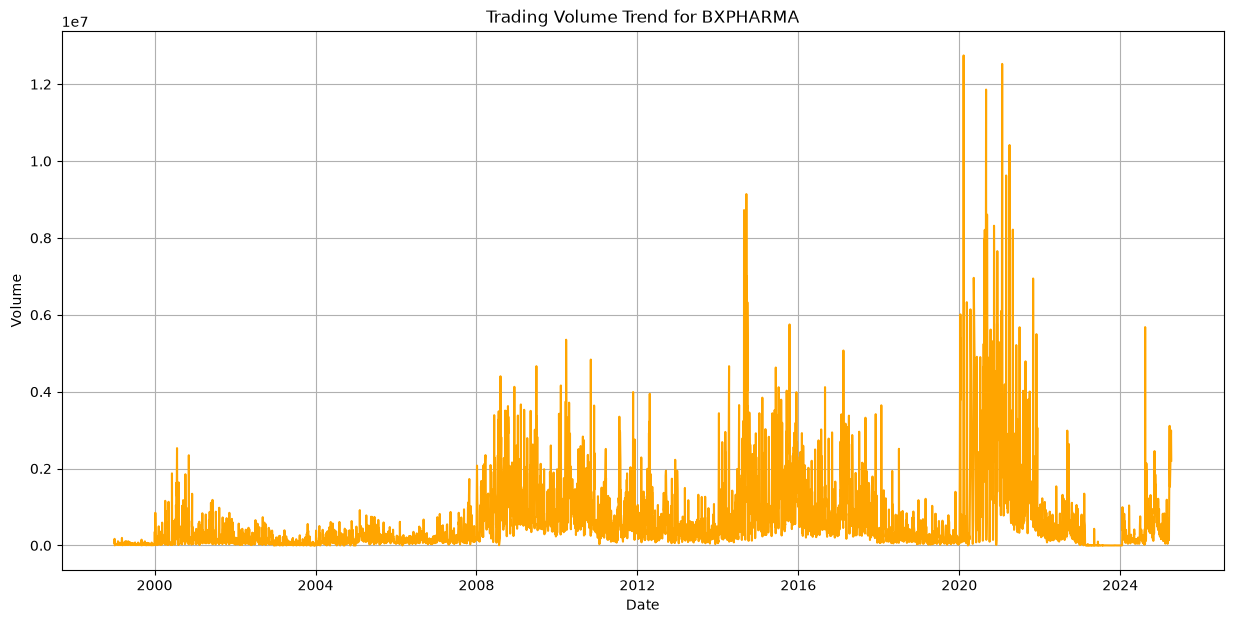

Descriptive statistics for Daily Return:


count    1.307129e+06
mean     2.016181e+00
std      7.648931e+01
min     -9.979508e+01
25%     -2.044393e+00
50%      0.000000e+00
75%      2.325581e+00
max      4.871250e+04
Name: Daily_Return, dtype: float64


Descriptive statistics for Volume:


count    1.307591e+06
mean     4.037545e+05
std      1.242465e+06
min      1.000000e+00
25%      6.925000e+03
50%      5.920000e+04
75%      3.119180e+05
max      9.400600e+07
Name: Volume, dtype: float64

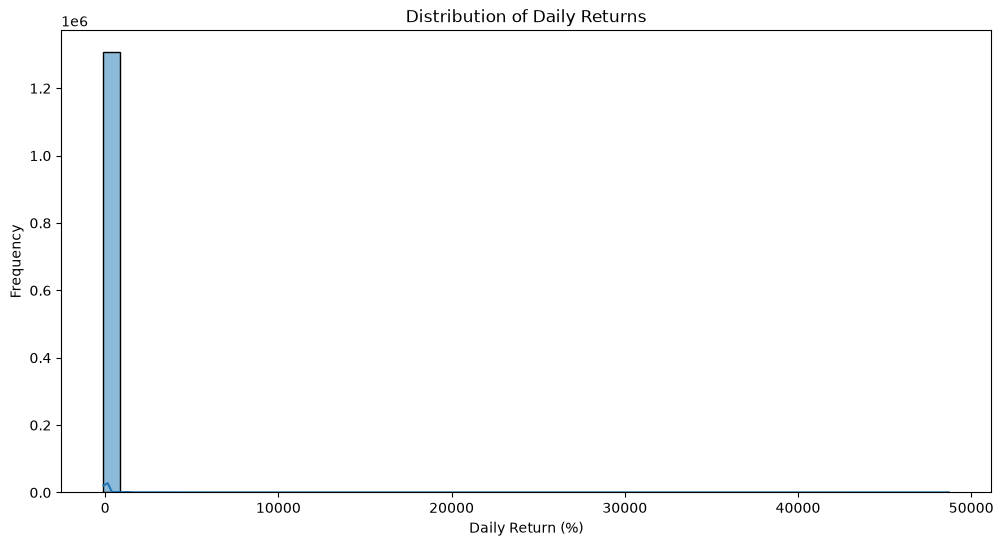

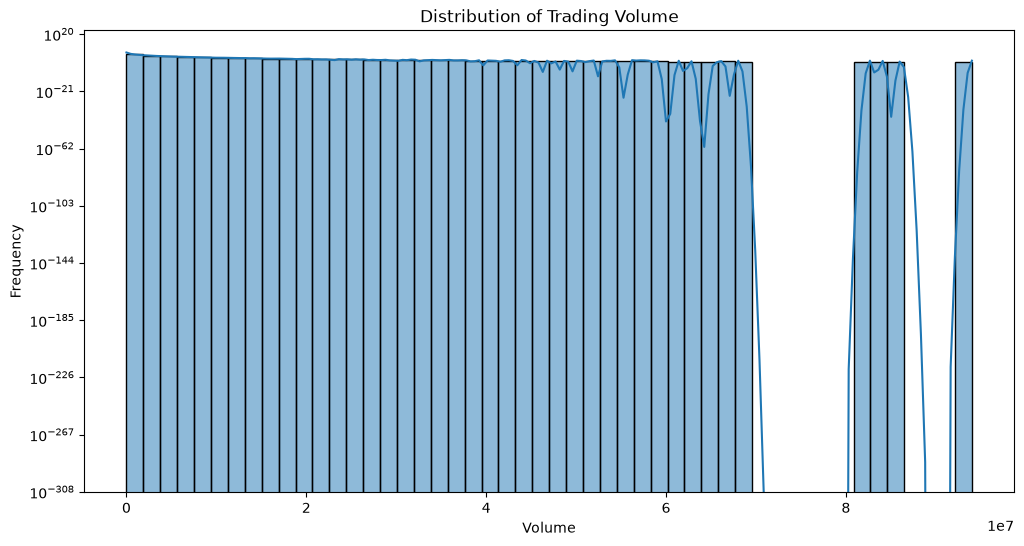


Top 10 Anomalous Daily Returns (extreme movements):


,Trading_Code,Date,Open,High,Low,Close,Volume,Daily_Return
1458546,USMANIAGL,2003-09-15,954.00,978.00,954.0,976.25,175.0,48712.500000
1483043,IDLC,2002-04-23,474.00,474.00,474.0,474.00,20.0,47300.000000
1481394,BDLAMPS,2002-06-05,305.00,308.00,305.0,306.00,80.0,15200.000000
1240285,ICBIBANK,2010-02-09,1985.00,2050.00,1938.0,2020.25,66365.0,10477.225131
1206413,ICBIBANK,2010-09-08,1741.00,1819.00,1740.0,1791.25,34275.0,9377.513228
1226551,ICBIBANK,2010-05-08,1559.00,1728.25,1559.0,1720.00,75500.0,9350.549451
1211406,ICBIBANK,2010-08-08,1660.25,1820.00,1610.0,1775.25,49215.0,9098.186528
1201181,ICBIBANK,2010-10-08,1810.00,1845.00,1745.0,1755.00,24705.0,8588.118812
1196190,ICBIBANK,2010-11-08,1740.00,1745.25,1653.0,1694.75,16250.0,8373.750000
1192341,ICBIBANK,2010-12-08,1666.75,1680.00,1650.0,1657.25,15295.0,8227.889447


,Trading_Code,Date,Open,High,Low,Close,Volume,Daily_Return
1410891,RUPALIBANK,2006-01-11,1909.0,1909.00,1853.00,1862.00,8920.0,231.611754
1301267,PRIMETEX,2009-01-12,427.5,429.00,416.00,418.00,19300.0,231.746032
1255221,PRIMETEX,2009-10-29,430.0,448.75,410.00,418.00,41450.0,231.746032
1327512,ABBANK,2008-07-05,4300.0,4350.00,4270.00,4307.00,43995.0,231.754285
973962,SAPORTL,2014-06-11,73.0,75.40,70.50,73.40,1596200.0,232.126697
396108,ARAMITCEM,2021-09-30,55.6,56.60,55.60,55.80,55477.0,232.142857
1330977,BDTHAI,2008-06-11,471.0,498.00,441.00,475.00,1900.0,232.167832
1340092,BDTHAI,2008-04-12,400.0,400.00,388.25,389.50,1960.0,232.196162
1301208,FUWANGCER,2009-01-12,427.0,439.75,423.00,437.75,161900.0,232.258065
539345,BATBC,2019-12-03,5100.0,5500.00,4546.10,4580.00,159122.0,232.413993



Top 10 Anomalous Trading Volumes (above 14946560.86):


,Trading_Code,Date,Open,High,Low,Close,Volume,Daily_Return
381342,ONEBANKLTD,2021-11-30,19.6,20.7,19.6,20.1,94006000.0,73.275862
377615,ONEBANKLTD,2021-12-14,15.8,15.8,14.2,14.6,86105504.0,1.388889
447898,IFIC,2021-03-01,15.0,16.7,14.7,16.6,84019198.0,21.167883
383352,ONEBANKLTD,2021-11-22,16.1,17.7,16.0,17.2,82677332.0,-8.021390
433891,IFIC,2021-05-01,16.6,17.9,16.4,16.6,68053974.0,74.736842
394244,IFIC,2021-10-08,15.2,16.4,15.2,16.2,66278435.0,-7.428571
458811,ROBI,2021-01-13,69.5,69.5,60.0,63.8,66258795.0,-8.987161
367132,UNIONBANK,2022-01-31,14.6,14.6,13.0,13.2,65931798.0,3.125000
433620,ROBI,2021-05-01,39.4,39.4,37.1,39.4,65498764.0,-8.372093
392301,IFIC,2021-10-17,17.9,19.2,17.7,18.7,62725249.0,2.185792


Top 10 most frequent Trading Codes:


Trading_Code
BXPHARMA      6377
EHL           6376
AMCL(PRAN)    6363
SQURPHARMA    6360
APEXFOODS     6349
AFTABAUTO     6347
ECABLES       6334
APEXTANRY     6328
SINGERBD      6326
MONNOCERA     6317
Name: count, dtype: int64


Bottom 10 least frequent Trading Codes:


Trading_Code
BEMCO         41
BDPLANT       33
MAGURAPLEX    12
HILLPLANT      9
FUWANGCER      6
BDSERVICE      4
PETROSYNTH     3
PHENIXLETH     2
BDHOTELS       1
HIMADRI        1
Name: count, dtype: int64

In [18]:
# Use the most frequently occurring stock for the initial trend plots
most_frequent_trading_code = (
    df['Trading_Code'].value_counts().index[0]
)

sample_df = (
    df[df['Trading_Code'] == most_frequent_trading_code]
    .sort_values('Date')
)

print(f"Analyzing trends for: {most_frequent_trading_code}")

# Closing price trend
plt.figure(figsize=(15, 7))
sns.lineplot(x='Date', y='Close', data=sample_df)
plt.title(f'Closing Price Trend for {most_frequent_trading_code}')
plt.xlabel('Date')
plt.ylabel('Closing Price')
plt.grid(True)
plt.show()

# Trading volume trend
plt.figure(figsize=(15, 7))
sns.lineplot(x='Date', y='Volume', data=sample_df, color='orange')
plt.title(f'Trading Volume Trend for {most_frequent_trading_code}')
plt.xlabel('Date')
plt.ylabel('Volume')
plt.grid(True)
plt.show()

# Calculate daily returns separately for each stock
df['Daily_Return'] = (
    df.groupby('Trading_Code')['Close'].pct_change() * 100
)

# Descriptive statistics
print("Descriptive statistics for Daily Return:")
display(df['Daily_Return'].describe())

print("\nDescriptive statistics for Volume:")
display(df['Volume'].describe())

# Distribution of daily returns
plt.figure(figsize=(12, 6))
sns.histplot(df['Daily_Return'].dropna(), bins=50, kde=True)
plt.title('Distribution of Daily Returns')
plt.xlabel('Daily Return (%)')
plt.ylabel('Frequency')
plt.show()

# Distribution of trading volume
plt.figure(figsize=(12, 6))
sns.histplot(df['Volume'].dropna(), bins=50, kde=True)
plt.title('Distribution of Trading Volume')
plt.xlabel('Volume')
plt.ylabel('Frequency')
plt.yscale('log')
plt.show()

# Look for unusually large daily returns
mean_return = df['Daily_Return'].mean()
std_return = df['Daily_Return'].std()

outlier_returns = df[
    (df['Daily_Return'] > (mean_return + 3 * std_return)) |
    (df['Daily_Return'] < (mean_return - 3 * std_return))
]

print("\nTop 10 Anomalous Daily Returns (extreme movements):")

display(
    outlier_returns
    .sort_values(by='Daily_Return', ascending=False)
    .head(10)
)

display(
    outlier_returns
    .sort_values(by='Daily_Return', ascending=True)
    .head(10)
)

# Look at the highest-volume observations (top 0.1%)
volume_threshold = df['Volume'].quantile(0.999)

outlier_volumes = df[df['Volume'] >= volume_threshold]

print(
    f"\nTop 10 Anomalous Trading Volumes "
    f"(above {volume_threshold:.2f}):"
)

display(
    outlier_volumes
    .sort_values(by='Volume', ascending=False)
    .head(10)
)

# Most and least frequent trading codes
print("Top 10 most frequent Trading Codes:")
display(df['Trading_Code'].value_counts().head(10))

print("\nBottom 10 least frequent Trading Codes:")
display(df['Trading_Code'].value_counts().tail(10))

In [19]:
# Save the cleaned dataset
output_path = r'C:\Users\samad_dthqblr\Downloads\Cleaned_DSE_Data.csv'

df.to_csv(output_path, index=False)

print(f"Cleaned data saved successfully to {output_path}")

Cleaned data saved successfully to C:\Users\samad_dthqblr\Downloads\Cleaned_DSE_Data.csv


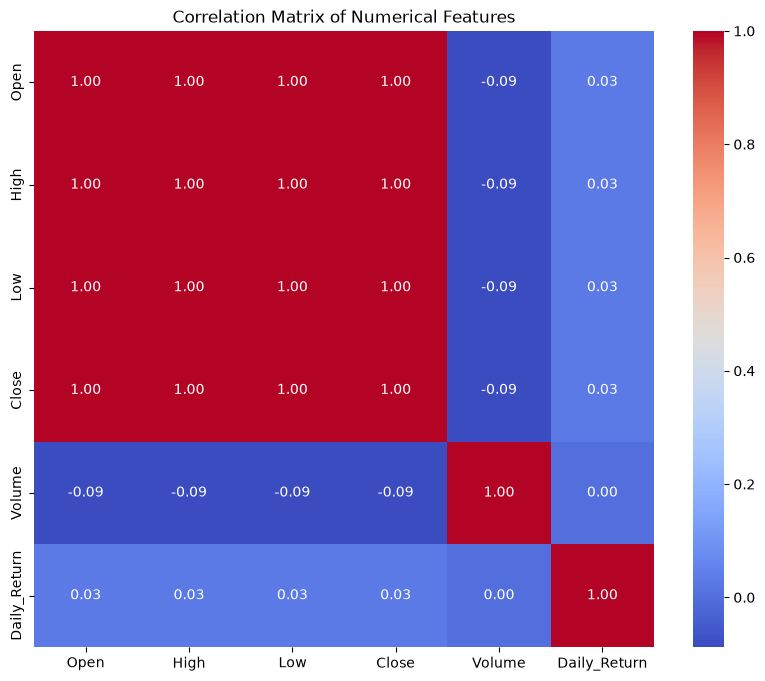

,Open,High,Low,Close,Volume,Daily_Return
Open,1.000000,0.999694,0.999744,0.999737,-0.087434,0.030719
High,0.999694,1.000000,0.999309,0.999592,-0.087512,0.030969
Low,0.999744,0.999309,1.000000,0.999853,-0.087238,0.030384
Close,0.999737,0.999592,0.999853,1.000000,-0.087301,0.030682
Volume,-0.087434,-0.087512,-0.087238,-0.087301,1.000000,0.001322
Daily_Return,0.030719,0.030969,0.030384,0.030682,0.001322,1.000000


In [20]:
# Correlation between the numerical variables
plt.figure(figsize=(10, 8))

sns.heatmap(
    df[['Open', 'High', 'Low', 'Close', 'Volume', 'Daily_Return']].corr(),
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title('Correlation Matrix of Numerical Features')
plt.show()

correlation_matrix = df[
    ['Open', 'High', 'Low', 'Close', 'Volume', 'Daily_Return']
].corr()

display(correlation_matrix)

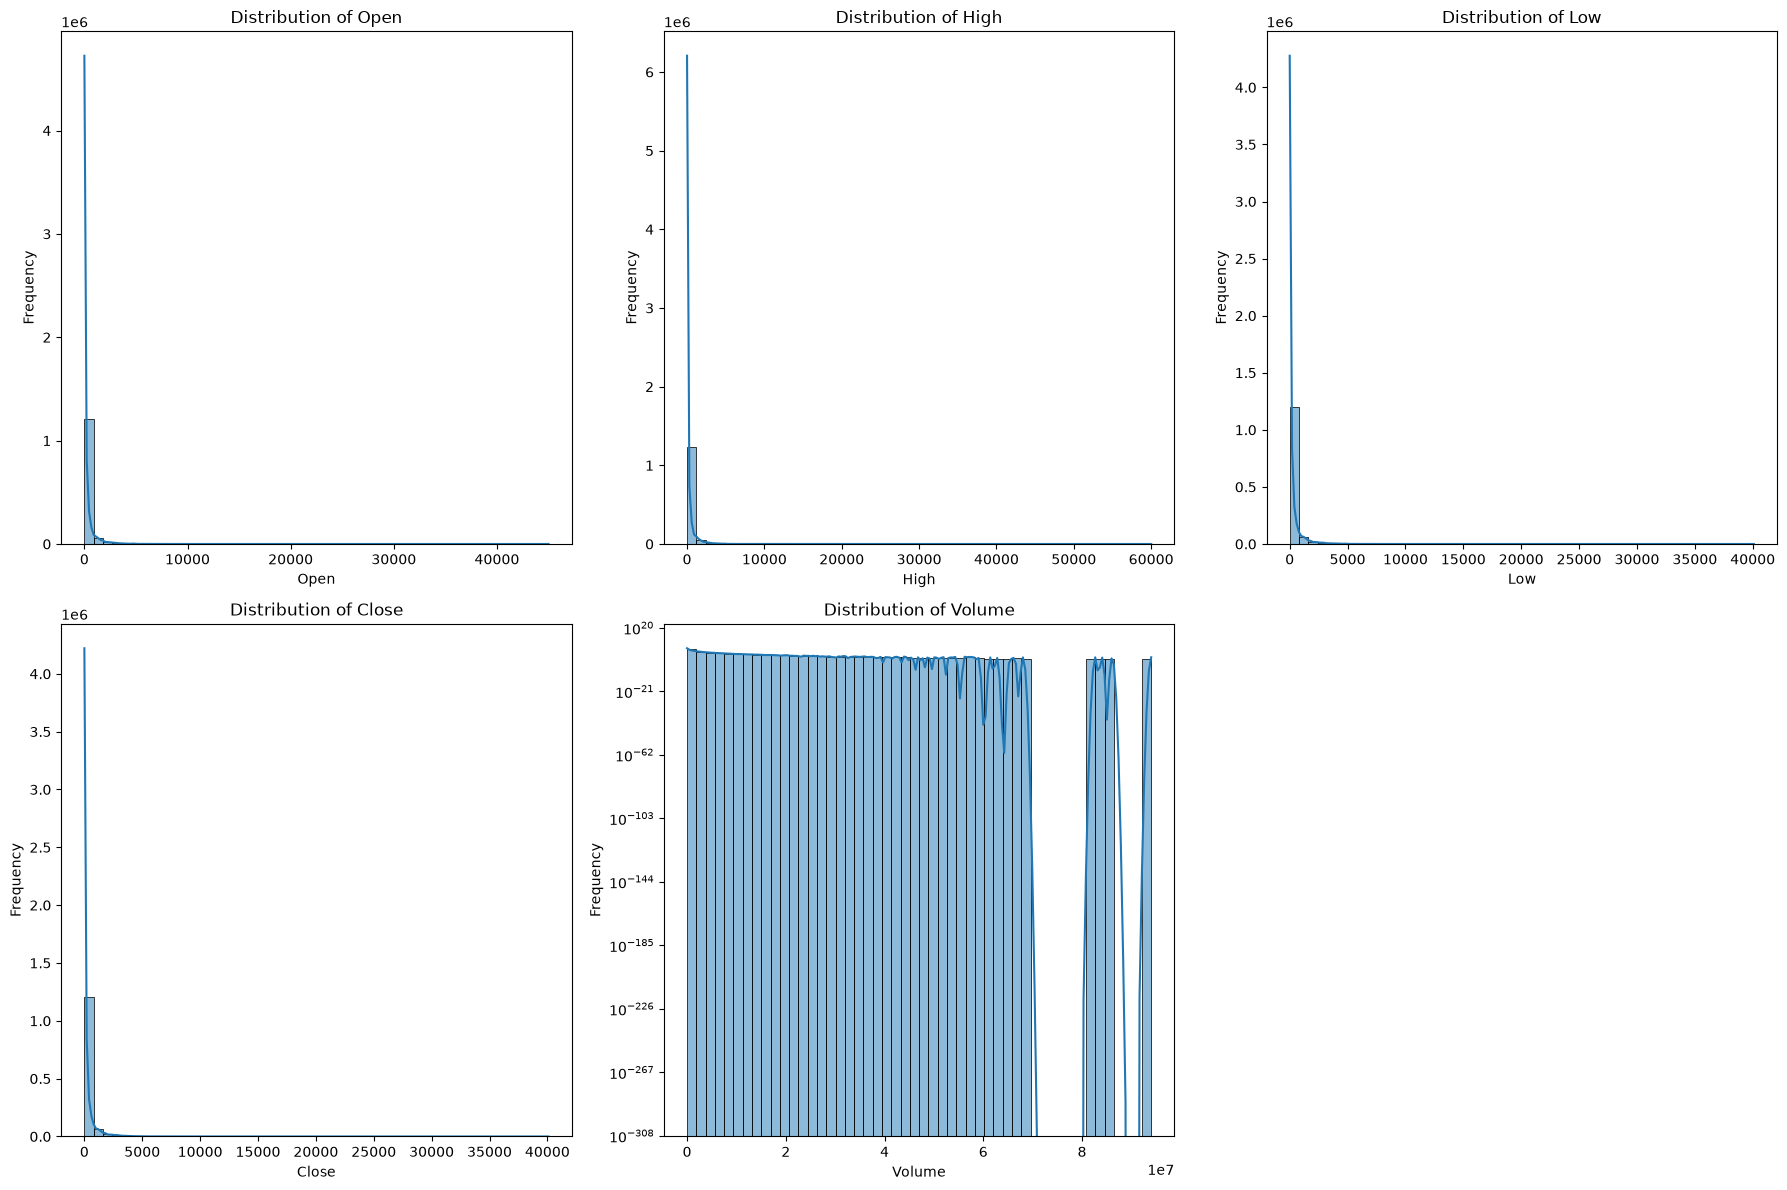

In [21]:
# Overall distribution of the main numerical features
numerical_features = ['Open', 'High', 'Low', 'Close', 'Volume']

plt.figure(figsize=(18, 12))

for i, col in enumerate(numerical_features):
    plt.subplot(2, 3, i + 1)
    sns.histplot(df[col], kde=True, bins=50)
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')

    if col == 'Volume':
        plt.yscale('log')

plt.tight_layout()
plt.show()

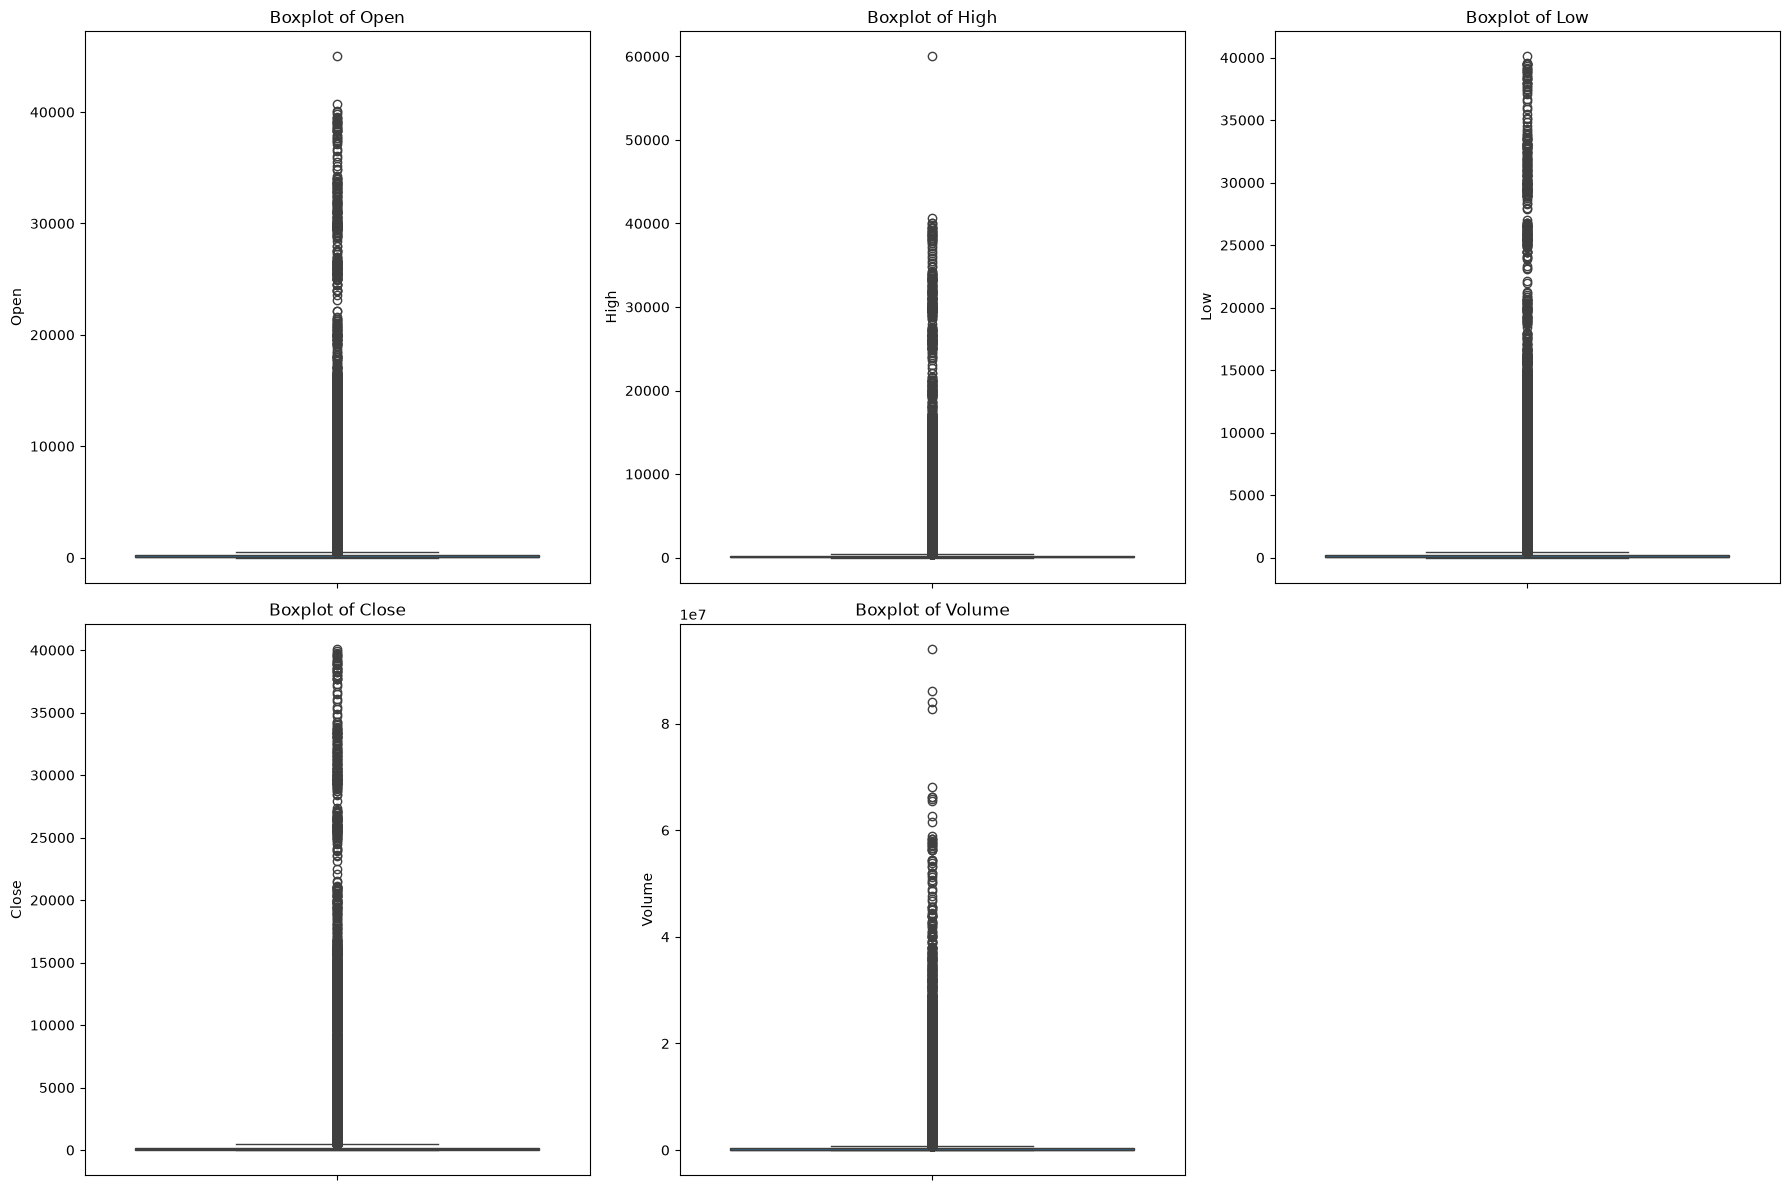

In [22]:
# Check the numerical features for outliers
plt.figure(figsize=(18, 12))

for i, col in enumerate(numerical_features):
    plt.subplot(2, 3, i + 1)
    sns.boxplot(y=df[col])
    plt.title(f'Boxplot of {col}')
    plt.ylabel(col)

plt.tight_layout()
plt.show()

## Feature Engineering

In [23]:
# Feature engineering
def create_features(df_input):
    df_output = df_input.copy()

    # Sort each stock by date before creating lag and rolling features
    df_output = df_output.sort_values(
        by=['Trading_Code', 'Date']
    )

    # The target is the next day's closing price
    df_output['Target_Close'] = (
        df_output.groupby('Trading_Code')['Close'].shift(-1)
    )

    # Add lagged values for the main market variables
    for col in ['Open', 'High', 'Low', 'Close', 'Volume']:
        for lag in [1, 2, 3, 5, 10]:
            df_output[f'{col}_Lag_{lag}'] = (
                df_output.groupby('Trading_Code')[col].shift(lag)
            )

    # Add simple and exponential moving averages
    for window in [5, 10, 20]:
        df_output[f'SMA_Close_{window}'] = (
            df_output.groupby('Trading_Code')['Close']
            .rolling(window=window)
            .mean()
            .reset_index(level=0, drop=True)
        )

        df_output[f'EMA_Close_{window}'] = (
            df_output.groupby('Trading_Code')['Close']
            .ewm(span=window, adjust=False)
            .mean()
            .reset_index(level=0, drop=True)
        )

    # Calendar-based features
    df_output['DayOfWeek'] = df_output['Date'].dt.dayofweek
    df_output['Month'] = df_output['Date'].dt.month
    df_output['Year'] = df_output['Date'].dt.year
    df_output['DayOfYear'] = df_output['Date'].dt.dayofyear
    df_output['WeekOfYear'] = (
        df_output['Date'].dt.isocalendar().week.astype(int)
    )
    df_output['Day'] = df_output['Date'].dt.day

    # Daily price movement features
    df_output['Daily_Range'] = (
        df_output['High'] - df_output['Low']
    )

    df_output['Open_Close_Diff'] = (
        df_output['Open'] - df_output['Close']
    )

    # Remove rows created with missing values from shifts and rolling windows
    df_output.dropna(inplace=True)

    return df_output


df_features = create_features(df)

print(f"Original DataFrame shape: {df.shape}")
print(f"DataFrame with features shape: {df_features.shape}")

display(df_features.head())


# Define the features and target
features = [
    col for col in df_features.columns
    if col not in ['Trading_Code', 'Date', 'Target_Close']
]

target = 'Target_Close'

X = df_features[features]
y = df_features[target]

print(f"Number of features: {len(features)}")
print(f"Features: {features[:5]}...")
print(f"Shape of X: {X.shape}")
print(f"Shape of y: {y.shape}")

Original DataFrame shape: (1307591, 8)
DataFrame with features shape: (1298473, 48)


,Trading_Code,Date,Open,High,Low,Close,Volume,Daily_Return,Target_Close,Open_Lag_1,...,SMA_Close_20,EMA_Close_20,DayOfWeek,Month,Year,DayOfYear,WeekOfYear,Day,Daily_Range,Open_Close_Diff
717551,AAMRANET,2017-10-15,116.6,119.9,104.0,107.2,1582407.0,4.483431,102.6,87.9,...,115.08,113.778772,6,10,2017,288,41,15,15.9,9.4
717272,AAMRANET,2017-10-16,107.7,111.8,101.0,102.6,1277864.0,-8.228980,111.8,116.6,...,114.47,112.714127,0,10,2017,289,42,16,10.8,5.1
717049,AAMRANET,2017-10-17,95.0,114.7,94.0,111.8,2484240.0,-2.015776,114.1,107.7,...,113.14,112.627067,1,10,2017,290,42,17,20.7,-16.8
716564,AAMRANET,2017-10-18,113.0,119.3,112.1,114.1,1514095.0,-0.696258,114.9,95.0,...,113.07,112.767347,2,10,2017,291,42,18,7.2,-1.1
716287,AAMRANET,2017-10-19,112.2,118.0,110.7,114.9,1588353.0,-1.878736,117.1,113.0,...,112.34,112.970456,3,10,2017,292,42,19,7.3,-2.7


Number of features: 45
Features: ['Open', 'High', 'Low', 'Close', 'Volume']...
Shape of X: (1298473, 45)
Shape of y: (1298473,)


In [24]:
# Time-series train/test split
train_end_date = pd.to_datetime('2023-12-31')

X_train = X[df_features['Date'] <= train_end_date]
y_train = y[df_features['Date'] <= train_end_date]

X_test = X[df_features['Date'] > train_end_date]
y_test = y[df_features['Date'] > train_end_date]

print(f"Training set size: {len(X_train)} samples")
print(f"Test set size: {len(X_test)} samples")

print(
    "First date in training set: "
    f"{df_features[df_features['Date'] <= train_end_date]['Date'].min().strftime('%Y-%m-%d')}"
)

print(
    "Last date in training set: "
    f"{df_features[df_features['Date'] <= train_end_date]['Date'].max().strftime('%Y-%m-%d')}"
)

print(
    "First date in test set: "
    f"{df_features[df_features['Date'] > train_end_date]['Date'].min().strftime('%Y-%m-%d')}"
)

print(
    "Last date in test set: "
    f"{df_features[df_features['Date'] > train_end_date]['Date'].max().strftime('%Y-%m-%d')}"
)

Training set size: 1193615 samples
Test set size: 104858 samples
First date in training set: 1999-02-06
Last date in training set: 2023-12-28
First date in test set: 2024-01-01
Last date in test set: 2025-04-07


In [26]:
# Train the LightGBM regression model
import lightgbm as lgb
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

lgbm = lgb.LGBMRegressor(
    objective='regression',
    num_leaves=31,
    learning_rate=0.05,
    n_estimators=1000,
    n_jobs=-1,
    random_state=42
)

print("Training LightGBM model...")
lgbm.fit(X_train, y_train)
print("Model training complete.")

Training LightGBM model...
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.449036 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 10318
[LightGBM] [Info] Number of data points in the train set: 1193615, number of used features: 45
[LightGBM] [Info] Start training from score 283.296338
Model training complete.


In [27]:
# Evaluate the model on the test set
print("Making predictions on the test set...")

y_pred = lgbm.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("\nModel Evaluation on Test Set:")
print(f"Mean Squared Error (MSE): {mse:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")
print(f"Mean Absolute Error (MAE): {mae:.4f}")
print(f"R-squared (R2): {r2:.4f}")

Making predictions on the test set...

Model Evaluation on Test Set:
Mean Squared Error (MSE): 1339.3508
Root Mean Squared Error (RMSE): 36.5971
Mean Absolute Error (MAE): 2.6777
R-squared (R2): 0.9886


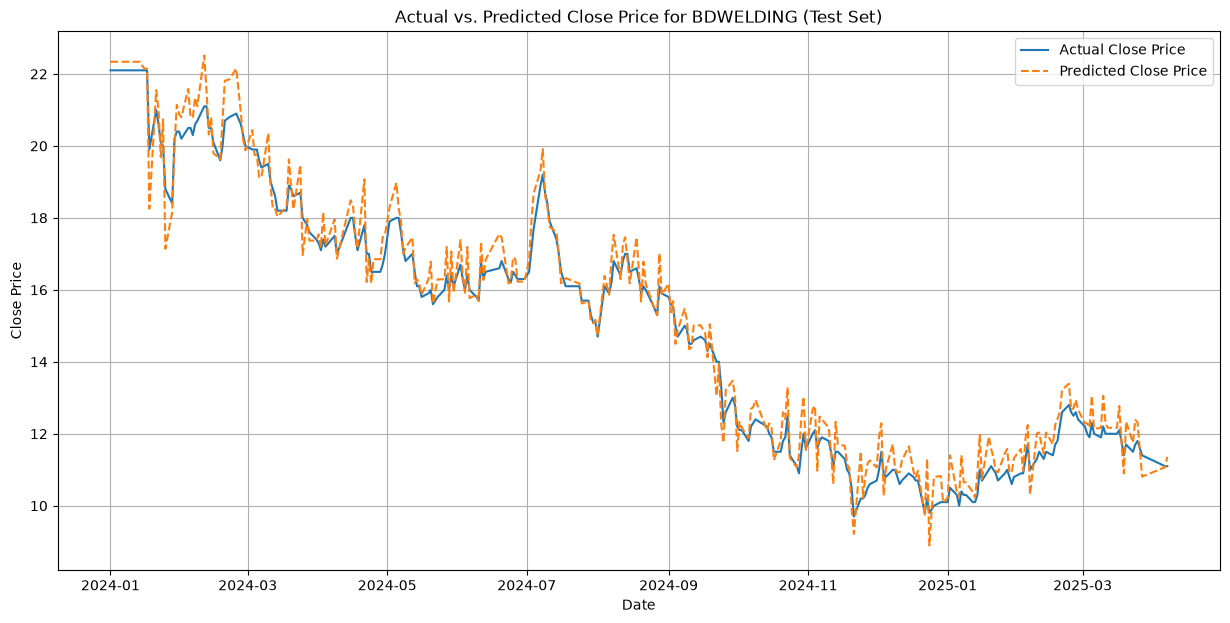

In [28]:
# Compare actual and predicted prices for a sample stock
df_test_results = df_features[
    df_features['Date'] > train_end_date
].copy()

df_test_results['Actual_Close'] = y_test
df_test_results['Predicted_Close'] = y_pred

sample_trading_code_test = (
    df_test_results['Trading_Code'].value_counts().index[0]
)

sample_test_df = (
    df_test_results[
        df_test_results['Trading_Code'] == sample_trading_code_test
    ]
    .sort_values('Date')
)

if not sample_test_df.empty:
    plt.figure(figsize=(15, 7))

    plt.plot(
        sample_test_df['Date'],
        sample_test_df['Actual_Close'],
        label='Actual Close Price'
    )

    plt.plot(
        sample_test_df['Date'],
        sample_test_df['Predicted_Close'],
        label='Predicted Close Price',
        linestyle='--'
    )

    plt.title(
        f'Actual vs. Predicted Close Price for '
        f'{sample_trading_code_test} (Test Set)'
    )
    plt.xlabel('Date')
    plt.ylabel('Close Price')
    plt.legend()
    plt.grid(True)
    plt.show()
else:
    print(
        f"No test data available for {sample_trading_code_test} "
        "after the split date. Cannot visualize."
    )

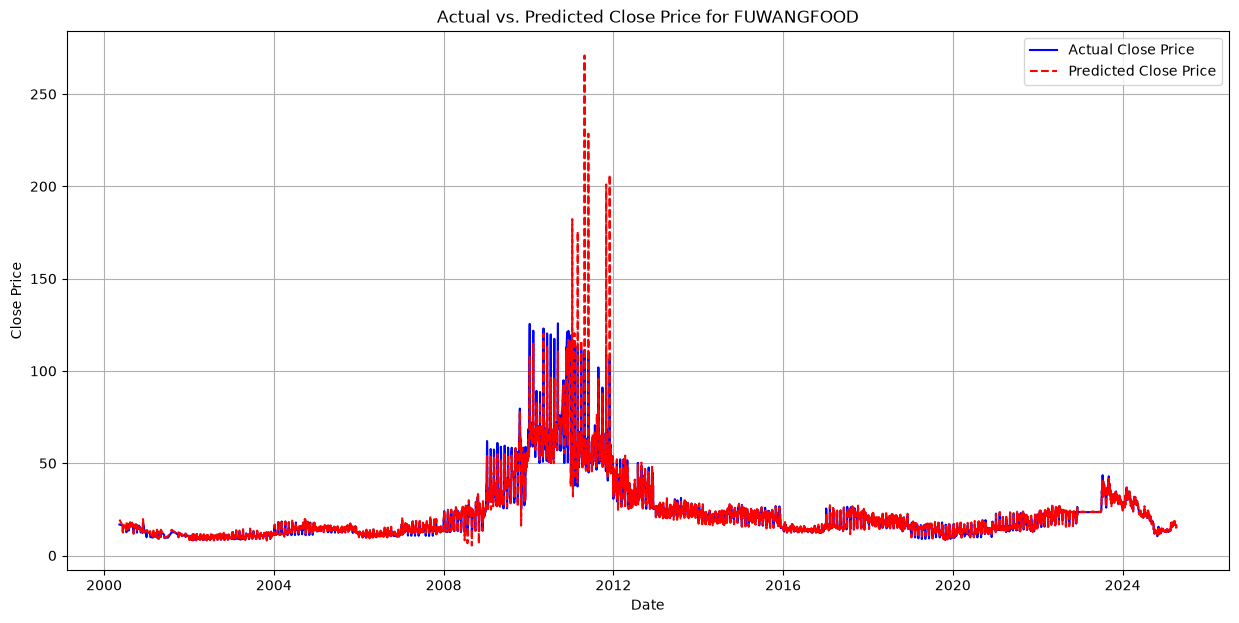

,Date,Actual_Close,Predicted_Close
2240,2025-03-24,17.1,17.231186
2085,2025-03-25,17.6,18.682450
1368,2025-03-27,16.7,15.467545
874,2025-04-06,16.5,16.541794
630,2025-04-07,15.4,14.666854


In [29]:
# Predict prices for one specific stock
import matplotlib.pyplot as plt

single_stock_to_predict = 'FUWANGFOOD'

df_single_stock_pred = df_features[
    df_features['Trading_Code'] == single_stock_to_predict
].copy()

df_single_stock_pred = df_single_stock_pred.sort_values(by='Date')

X_single_stock = df_single_stock_pred[features]
y_single_stock_actual = df_single_stock_pred[target]

if 'lgbm' in locals():
    single_stock_predictions = lgbm.predict(X_single_stock)
else:
    print(
        "Error: LightGBM model 'lgbm' not found. "
        "Please ensure the training cell was executed."
    )
    single_stock_predictions = []

df_single_stock_pred['Predicted_Close'] = single_stock_predictions
df_single_stock_pred['Actual_Close'] = y_single_stock_actual

if not df_single_stock_pred.empty:
    plt.figure(figsize=(15, 7))

    plt.plot(
        df_single_stock_pred['Date'],
        df_single_stock_pred['Actual_Close'],
        label='Actual Close Price',
        color='blue'
    )

    plt.plot(
        df_single_stock_pred['Date'],
        df_single_stock_pred['Predicted_Close'],
        label='Predicted Close Price',
        color='red',
        linestyle='--'
    )

    plt.title(
        f'Actual vs. Predicted Close Price for '
        f'{single_stock_to_predict}'
    )
    plt.xlabel('Date')
    plt.ylabel('Close Price')
    plt.legend()
    plt.grid(True)
    plt.show()
else:
    print(
        f"No data available for {single_stock_to_predict} "
        "after feature engineering."
    )

display(
    df_single_stock_pred[
        ['Date', 'Actual_Close', 'Predicted_Close']
    ].tail()
)

In [30]:
# Predict the price for a specific future date
target_prediction_date_str = '2026-06-08'
target_prediction_date = pd.to_datetime(target_prediction_date_str)

single_stock_to_predict = 'FUWANGFOOD'

# Use the last available feature set as the starting point
base_features_for_prediction = (
    df_single_stock_pred[features].iloc[[-1]].copy()
)

X_future_predict = base_features_for_prediction.copy()

# Update only the date-related features for the target date
X_future_predict['DayOfWeek'] = target_prediction_date.dayofweek
X_future_predict['Month'] = target_prediction_date.month
X_future_predict['Year'] = target_prediction_date.year
X_future_predict['DayOfYear'] = target_prediction_date.dayofyear
X_future_predict['WeekOfYear'] = (
    target_prediction_date.isocalendar().week
)
X_future_predict['Day'] = target_prediction_date.day

# Generate the future price prediction
future_prediction = lgbm.predict(X_future_predict)

print(
    f"Predicted Close price for {single_stock_to_predict} "
    f"on {target_prediction_date_str}: {future_prediction[0]:.2f}"
)

# Show the feature values used for the prediction
print(
    "\nFeatures used for prediction "
    "(last known numerical features with updated date components):"
)

display(X_future_predict.head())

Predicted Close price for FUWANGFOOD on 2026-06-08: 14.67

Features used for prediction (last known numerical features with updated date components):


,Open,High,Low,Close,Volume,Daily_Return,Open_Lag_1,Open_Lag_2,Open_Lag_3,Open_Lag_5,...,SMA_Close_20,EMA_Close_20,DayOfWeek,Month,Year,DayOfYear,WeekOfYear,Day,Daily_Range,Open_Close_Diff
630,16.9,17.1,16.3,16.5,1948743.0,7.142857,17.1,17.4,17.5,17.5,...,16.825,16.729324,0,6,2026,159,24,8,0.8,0.4
